# Lilylet→MIDI FREE-GENERATION — onset comparison

Sibling of `midiMeasurewise_inspect.ipynb` §6 (which compares the DATASET's ground-truth MIDI
onsets to its lilylet). This one compares the onsets of the model's **freely-generated** MIDI to
the onsets of the **source lilylet score** it was conditioned on — i.e. does the model place notes
at the right times within each measure, given only the score?

- lilylet onsets: from the AST server (`lilylet/tools/astServer.ts`, POST /onsets) → `onsetNorm`
  (0=barline, 1=next barline) × MIDI pitch, per measure.
- MIDI onsets: reconstruct absolute tick by accumulating deltaTime over the generated event
  stream, bucket note_on onsets by their OWN generated measure, normalize within each measure.
- Overlay per measure: lilylet (blue o) vs generated MIDI (red x). Good conditioning → the x's
  track the o's in both time (x-axis) and pitch (y-axis).

Best model to date: `20260705-…-nota0703-w8` (wide-window; best free-running measure retention).

Prereq: start the AST server first —
`cd ~/work/lilylet && npx tsx tools/astServer.ts --port 8788`

In [1]:
from pathlib import Path
import sys, os, json, urllib.request, collections

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'starry').is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
from starry.midi.tokenizer import MidiTokenizer

AST_SERVER = 'http://127.0.0.1:8788'
# the generated MIDI file (from gen_midi_from_lilylet.py) + its SOURCE lilylet.
GEN_DIR = REPO_ROOT / 'tests' / 'output' / 'midi_from_lilylet_w8_onset'
SRC_DIR = Path.home() / 'work' / 'lilylet' / 'tests' / 'output' / 'notagenx-from-abc'
gen_files = sorted(GEN_DIR.glob('*.midi.txt'))
assert gen_files, f'no generated files in {GEN_DIR} — run gen_midi_from_lilylet.py --out-dir it first'
GEN = gen_files[0]
NAME = GEN.name[:-len('.midi.txt')]
LYL = SRC_DIR / (NAME + '.lyl')
print('generated:', GEN.name)
print('source lyl:', LYL, '| exists:', LYL.exists())
mt = MidiTokenizer()

generated: 20250409_160536_Classical_Schubert, Franz_Art Song_postinst.midi.txt
source lyl: /home/camus/work/lilylet/tests/output/notagenx-from-abc/20250409_160536_Classical_Schubert, Franz_Art Song_postinst.lyl | exists: True


## 1. Lilylet onsets from the AST server (per measure)

POST the source lilylet; get `onsetNorm × midi` points per measure. Chords → one point per pitch.

In [2]:
def query_onsets(code):
    req = urllib.request.Request(AST_SERVER + '/onsets',
        data=json.dumps({'code': code}).encode(), headers={'Content-Type': 'application/json'})
    return json.load(urllib.request.urlopen(req, timeout=30))

lyl_code = open(LYL, encoding='utf-8').read()
resp = query_onsets(lyl_code)
assert resp['ok'], resp.get('error')
# measure index -> list of (onsetNorm, pitch)
lyl_by_measure = {}
for m in resp['measures']:
    pts = [(n['onsetNorm'], p) for n in m['notes'] for p in n['midi']]
    lyl_by_measure[m['index']] = pts
print('lilylet measures with onsets:', len(lyl_by_measure))
print('measure indices:', sorted(lyl_by_measure)[:20], '...' if len(lyl_by_measure) > 20 else '')

lilylet measures with onsets: 17
measure indices: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17] 


## 2. Generated-MIDI onsets (per generated measure)

Accumulate deltaTime over the generated event stream to get absolute tick; `<eom>` patches mark
measure boundaries (increment the measure counter, no deltaTime). Bucket note_on onsets per
measure, normalize within each measure's [start, next-start) tick span.

In [3]:
lines = [ln for ln in open(GEN, encoding='utf-8').read().split('\n') if ln.strip()]
abst = 0
cur = 1                      # first body measure (header events sit before the first % eom)
per_measure = collections.defaultdict(list)   # measure -> [(abs_tick, pitch)]
measure_start = {}                            # measure -> first abs_tick
for ln in lines:
    # measure-boundary comment emitted by the generator at each <eom> ("%% eom N")
    if ln.lstrip().startswith('%'):
        toks = ln.replace('%', ' ').split()
        if len(toks) >= 2 and toks[0] == 'eom':
            cur = int(toks[1]) + 1            # events after this belong to the NEXT measure
        continue
    parts = ln.split()
    head = parts[0]
    if head in ('ticks_per_beat', 'format_type', 'track'):
        continue                              # header, no deltaTime
    if len(parts) >= 2:
        try: delta = int(parts[1], 16)
        except ValueError: delta = 0
    else:
        delta = 0
    abst += delta
    measure_start.setdefault(cur, abst)
    if head == 'note_on' and len(parts) >= 5:
        try: vel = int(parts[4], 16)
        except ValueError: vel = 0
        if vel > 0:
            try: pitch = int(parts[3], 16)
            except ValueError: pitch = 0
            per_measure[cur].append((abst, pitch))

# measure spans from sorted first-ticks (for within-measure onset normalization).
ms = sorted(measure_start)
def span(mi):
    s = measure_start[mi]
    later = [measure_start[m] for m in ms if measure_start[m] > s]
    e = min(later) if later else max((t for pts in per_measure.values() for t, _ in pts), default=s + 1)
    return s, max(e, s + 1)

midi_by_measure = {}
for mi in per_measure:
    s, e = span(mi); d = e - s
    midi_by_measure[mi] = [((t - s) / d, p) for t, p in per_measure[mi]]
print('generated measures with note_on:', len(midi_by_measure))
print('total generated note_on onsets:', sum(len(v) for v in midi_by_measure.values()))

generated measures with note_on: 15
total generated note_on onsets: 185


## 3. Per-measure onset overlay — lilylet (o) vs generated MIDI (x)

The generated measure index aligns 1:1 with the lilylet measure index (identity src alignment,
no-repeat generation). Plot the first N measures where both have content.

measures shown: [1, 3, 4, 5, 8, 9, 10, 11]


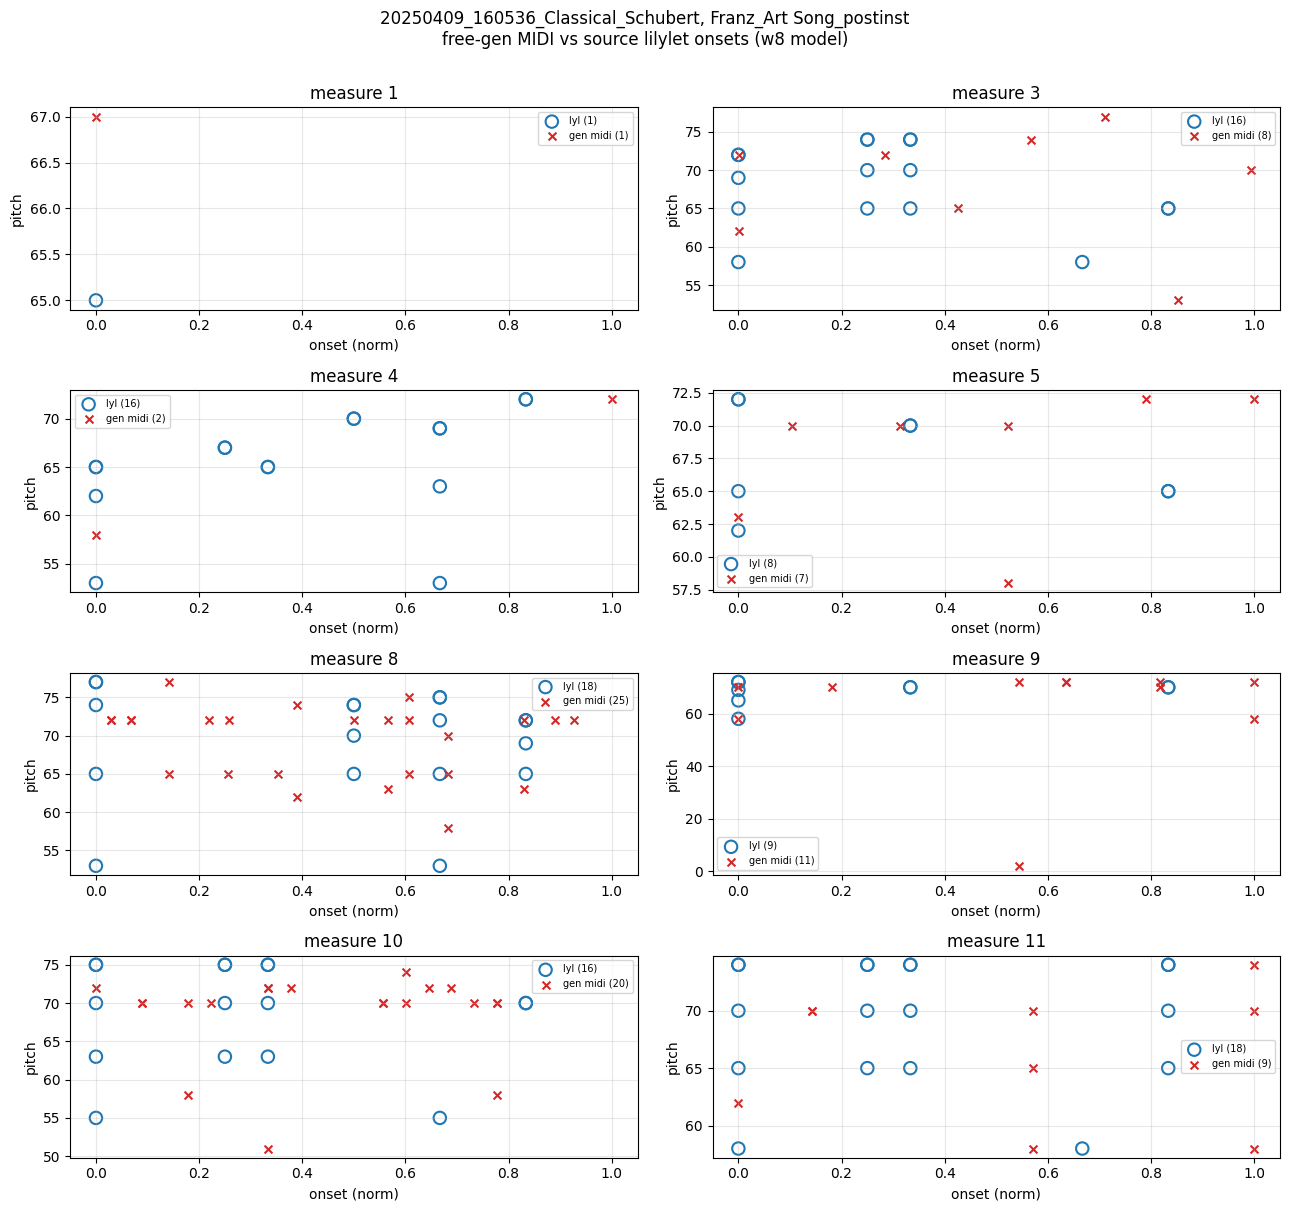

In [4]:
N_SHOW = 8
common = [m for m in sorted(lyl_by_measure) if m in midi_by_measure and lyl_by_measure[m]][:N_SHOW]
print('measures shown:', common)
ncol = 2
nrow = (len(common) + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 3.0 * nrow), squeeze=False)
for k, m in enumerate(common):
    ax = axes[k // ncol][k % ncol]
    lp = lyl_by_measure[m]; mp = midi_by_measure.get(m, [])
    if lp:
        lx, ly = zip(*lp); ax.scatter(lx, ly, s=80, marker='o', facecolors='none',
            edgecolors='tab:blue', linewidths=1.5, label=f'lyl ({len(lp)})')
    if mp:
        mx, my = zip(*mp); ax.scatter(mx, my, s=32, marker='x', color='tab:red',
            label=f'gen midi ({len(mp)})')
    ax.set_title(f'measure {m}'); ax.set_xlim(-0.05, 1.05); ax.grid(True, alpha=0.3)
    ax.set_xlabel('onset (norm)'); ax.set_ylabel('pitch'); ax.legend(loc='best', fontsize=7)
for k in range(len(common), nrow * ncol):
    axes[k // ncol][k % ncol].axis('off')
plt.suptitle(f'{NAME}\nfree-gen MIDI vs source lilylet onsets (w8 model)', y=1.005)
plt.tight_layout(); plt.show()

## 4. Aggregate onset alignment

Pool all shown measures: overlay every (onsetNorm, pitch) point, and report a coarse pitch-set
overlap per measure (how many lilylet pitches the generated MIDI reproduces).

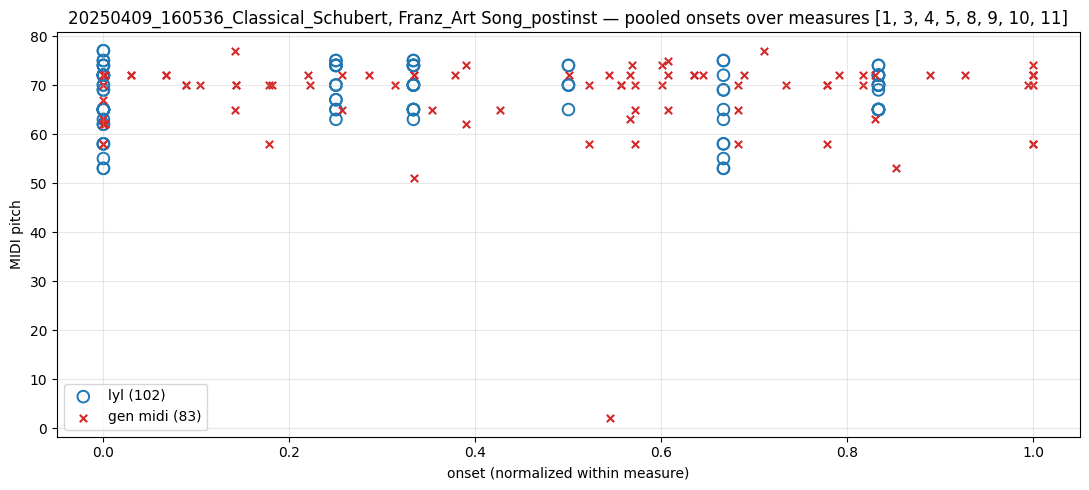

per-measure pitch-set overlap (|gen ∩ lyl| / |lyl|):
  measure  1: lyl_pitches= 1 gen_pitches= 1 overlap=0.00
  measure  3: lyl_pitches= 6 gen_pitches= 7 overlap=0.67
  measure  4: lyl_pitches= 8 gen_pitches= 2 overlap=0.12
  measure  5: lyl_pitches= 4 gen_pitches= 4 overlap=0.50
  measure  8: lyl_pitches= 8 gen_pitches= 9 overlap=0.75
  measure  9: lyl_pitches= 5 gen_pitches= 4 overlap=0.60
  measure 10: lyl_pitches= 4 gen_pitches= 5 overlap=0.25
  measure 11: lyl_pitches= 4 gen_pitches= 5 overlap=1.00


In [5]:
allx_l = [x for m in common for x, _ in lyl_by_measure[m]]
ally_l = [y for m in common for _, y in lyl_by_measure[m]]
allx_m = [x for m in common for x, _ in midi_by_measure.get(m, [])]
ally_m = [y for m in common for _, y in midi_by_measure.get(m, [])]
fig, ax = plt.subplots(figsize=(11, 5))
if allx_l: ax.scatter(allx_l, ally_l, s=70, marker='o', facecolors='none', edgecolors='tab:blue', linewidths=1.4, label=f'lyl ({len(allx_l)})')
if allx_m: ax.scatter(allx_m, ally_m, s=28, marker='x', color='tab:red', label=f'gen midi ({len(allx_m)})')
ax.set_xlabel('onset (normalized within measure)'); ax.set_ylabel('MIDI pitch')
ax.set_title(f'{NAME} — pooled onsets over measures {common}')
ax.set_xlim(-0.05, 1.05); ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

print('per-measure pitch-set overlap (|gen ∩ lyl| / |lyl|):')
for m in common:
    lyl_p = {p for _, p in lyl_by_measure[m]}
    gen_p = {p for _, p in midi_by_measure.get(m, [])}
    if lyl_p:
        ov = len(lyl_p & gen_p) / len(lyl_p)
        print('  measure %2d: lyl_pitches=%2d gen_pitches=%2d overlap=%.2f' % (m, len(lyl_p), len(gen_p), ov))

## Notes

- x-axis = onset within measure (0 barline → 1 next barline); y-axis = MIDI pitch. Good conditioning
  → red x's sit near blue o's on both axes.
- MIDI realizes the score, so exact overlap isn't expected: octave doublings, arpeggiation of
  chords, and ornament/grace timing all shift points legitimately. Read the plot for *structural*
  agreement (right rhythmic slots, right pitch region), not point-for-point identity.
- Uses the type-penalty decode so the generation actually spans multiple measures; a collapsed
  (repeated-event) generation would show a degenerate vertical smear at one pitch.